In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("mini_dataset_translations/mini_dataset_translation_df.csv")
df.tail(20)

,Unnamed: 0,scene,transf_id,transf_type,transf_dx,dataset,ref_img,img_height,img_width,img_rel_path,label_rel_path,label_list,class_label,yolo_bbox,yolo_bbox_xcenter,yolo_bbox_ycenter,yolo_bbox_bbox_width,yolo_bbox_bbox_height
210,210,21,0,xtrans,0,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151, 0.35760099999999995, 0.236083, 0.66...",0.119151,0.357601,0.236083,0.668633
211,211,21,1,xtrans,-50,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.099065, 0.35760099999999995, 0.19813, 0.668...",0.119151,0.357601,0.236083,0.668633
212,212,21,2,xtrans,-100,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.07953375, 0.35760099999999995, 0.1590675, 0...",0.119151,0.357601,0.236083,0.668633
213,213,21,3,xtrans,-150,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.0600025, 0.35760099999999995, 0.120005, 0.6...",0.119151,0.357601,0.236083,0.668633
214,214,21,4,xtrans,-200,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.04047125, 0.35760099999999995, 0.0809425, 0...",0.119151,0.357601,0.236083,0.668633
215,215,21,5,xtrans,-250,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151,0.3576009999999999,0.236083,0.668632...",0.119151,0.357601,0.236083,0.668633
216,216,21,6,xtrans,-300,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151,0.3576009999999999,0.236083,0.668632...",0.119151,0.357601,0.236083,0.668633
217,217,21,7,xtrans,-350,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151,0.3576009999999999,0.236083,0.668632...",0.119151,0.357601,0.236083,0.668633
218,218,21,8,xtrans,-400,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151,0.3576009999999999,0.236083,0.668632...",0.119151,0.357601,0.236083,0.668633
219,219,21,9,xtrans,-450,pyronear_fp,Pyronear_st_peray_1_2023_04_26T06_01_19.jpg,720,1280,mini_dataset_translations/no_wildfire--pyronea...,mini_dataset_translations/no_wildfire--pyronea...,no_wildfire,0.0,"[0.119151,0.3576009999999999,0.236083,0.668632...",0.119151,0.357601,0.236083,0.668633


In [3]:
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def load_and_process_image(image_path, bbox, target_size=(224, 224)):
    """
    Charge et traite une image : recadre selon la bbox et redimensionne.
    """

    image = cv2.imread(image_path)

    x_center, y_center, width, height = bbox
    x_center *= image.shape[1]
    y_center *= image.shape[0]
    width *= image.shape[1]
    height *= image.shape[0]
    x = int(x_center - width / 2)
    y = int(y_center - height / 2)
    
    cropped_image = image[y:y+int(height), x:x+int(width)]
    cropped_height, cropped_width = cropped_image.shape[:2]

    resized_image = cv2.resize(cropped_image, target_size)
    
    image_array = img_to_array(resized_image)
    preprocessed_image = preprocess_input(image_array)
    
    return preprocessed_image

def prepare_sequences(df, sequence_length=10):
    """
    Prépare les séquences d'images pour l'entrée du modèle.
    """
    X = []
    y = []
    
    grouped = df.sort_values(by=['scene', 'transf_id']).groupby('scene')
    
    for _, group in grouped:
        images = []
        y_temp = []
        for _, row in group.iterrows():
            image_path = row['img_rel_path']
            bbox = row[['yolo_bbox_xcenter', 'yolo_bbox_ycenter', 'yolo_bbox_bbox_width', 'yolo_bbox_bbox_height']]
            processed_image = load_and_process_image(image_path, bbox)
            images.append(processed_image)
            y_temp.append(row['class_label'])
            if len(images) == sequence_length:
                X.append(np.array(images))
                y.append(np.array(y_temp))
    
    return np.array(X), np.array(y)

df['img_rel_path'] = df['img_rel_path']

X, y = prepare_sequences(df)


mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_000_50_0.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_050_50_1.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_100_50_2.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_150_50_3.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_200_50_4.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_250_50_5.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_300_50_6.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_00_50/0674_xtrans_350_50_7.jpg
19 32
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[0.7847655, 0.48125, 0.0382809999999999, 0.0375]
mini_dataset_translations/has_wildfire--DS-71c1fd51-sam-synthetic/images/scene_06_-50/0834_xtrans_-250_-50_5.jpg
27 48


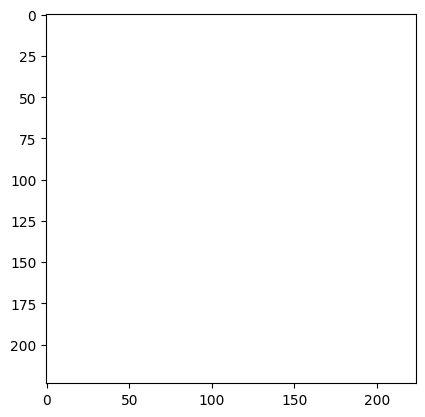

In [4]:
import matplotlib.pyplot as plt
i=65
bbox = list(df[['yolo_bbox_xcenter', 'yolo_bbox_ycenter', 'yolo_bbox_bbox_width', 'yolo_bbox_bbox_height']].iloc[i])
print(bbox)
image = cv2.imread(df['img_rel_path'][i])
image2 = load_and_process_image(df['img_rel_path'][i],bbox)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))


In [5]:
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50

def build_teacher_model(sequence_length=10, num_classes=10):
    resnet = ResNet50(include_top=False, weights='imagenet', pooling='avg')
    resnet.trainable = False

    input_shape = (sequence_length, 224, 224, 3)
    inputs = Input(shape=input_shape)

    time_distributed_resnet = TimeDistributed(resnet)(inputs)


    x = time_distributed_resnet
    for _ in range(2):
        x = LSTM(256, return_sequences=True)(x)
    x = LSTM(256, return_sequences=False)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

teacher_model = build_teacher_model()
teacher_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 10, 224, 224, 3   0         
                             )]                                  
                                                                 
 time_distributed (TimeDist  (None, 10, 2048)          23587712  
 ributed)                                                        
                                                                 
 lstm (LSTM)                 (None, 10, 256)           2360320   
                                                                 
 lstm_1 (LSTM)               (None, 10, 256)           525312    
                                                                 
 lstm_2 (LSTM)               (None, 256)               525312    
                                                                 
 dense (Dense)               (None, 10)                2570  

In [6]:
def build_student_model(sequence_length=10, num_classes=10):
    resnet = ResNet50(include_top=False, weights='imagenet', pooling='avg')
    resnet.trainable = False

    input_shape = (sequence_length, 224, 224, 3)
    inputs = Input(shape=input_shape)

    time_distributed_resnet = TimeDistributed(resnet)(inputs)

    x = LSTM(256, return_sequences=False)(time_distributed_resnet)

    if sequence_length > 1:
        outputs = Dense(num_classes, activation='softmax')(x)
    else:
        outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

student_model = build_student_model()
student_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 10, 224, 224, 3   0         
                             )]                                  
                                                                 
 time_distributed_1 (TimeDi  (None, 10, 2048)          23587712  
 stributed)                                                      
                                                                 
 lstm_3 (LSTM)               (None, 256)               2360320   
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 25950602 (98.99 MB)
Trainable params: 2362890 (9.01 MB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


In [29]:
import tensorflow as tf
from tensorflow.keras.metrics import CategoricalAccuracy, CategoricalCrossentropy
from tensorflow.keras.losses import categorical_crossentropy

def validate(val_dataset, student_model):
    accuracy_metric = CategoricalAccuracy()
    
    for images, labels in val_dataset:
        logits = student_model(images, training=False)
        accuracy_metric.update_state(labels, tf.nn.softmax(logits))
        
    return accuracy_metric.result().numpy()

def distillation_loss(teacher_logits, student_logits, true_labels, temperature, alpha):
    soft_labels = tf.nn.softmax(teacher_logits / temperature)

    student_loss = categorical_crossentropy(
        y_true=soft_labels, 
        y_pred=student_logits / temperature, 
        from_logits=True
    )
    
    label_loss = categorical_crossentropy(
        y_true=true_labels, 
        y_pred=student_logits, 
        from_logits=True
    )
    
    student_loss_mean = tf.reduce_mean(student_loss)
    label_loss_mean = tf.reduce_mean(label_loss)
    
    combined_loss = (alpha * student_loss_mean) + ((1 - alpha) * label_loss_mean)
    
    return combined_loss


@tf.function
def train_step(images, labels, student_model, teacher_model, optimizer, temperature=5.0, alpha=0.5):
    with tf.GradientTape() as tape:
        teacher_logits = teacher_model(images, training=False)
        student_logits = student_model(images, training=True)
        
        loss = distillation_loss(teacher_logits, student_logits, labels, temperature, alpha)
        
    gradients = tape.gradient(loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, student_model.trainable_variables))
    return loss

@tf.function
def train_step_simple(images, labels, model, optimizer):
    with tf.GradientTape() as tape:
        logits = model(images, training=True)
        loss = tf.keras.losses.categorical_crossentropy(labels, logits, from_logits=True)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss




In [30]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Mean

def train_student_with_distillation(student_model, teacher_model, train_dataset, val_dataset, epochs=10, temperature=5.0, alpha=0.5):
    optimizer = Adam()
    loss_metric = Mean()
    accuracy_metric = CategoricalAccuracy()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        loss_metric.reset_states()
        accuracy_metric.reset_states()

        for batch, (images, labels) in enumerate(train_dataset):
            loss = train_step(images, labels, student_model, teacher_model, optimizer, temperature, alpha)
            loss_metric.update_state(loss)

            preds = tf.nn.softmax(student_model(images, training=False))
            accuracy_metric.update_state(labels, preds)

            if batch % 10 == 0:
                print(f"Batch {batch}, Loss: {loss_metric.result().numpy()}, Accuracy: {accuracy_metric.result().numpy()}")

        print(f"Training Loss: {loss_metric.result().numpy()}")
        print(f"Training Accuracy: {accuracy_metric.result().numpy()}")

        val_accuracy = validate(val_dataset, student_model)
        print(f"Validation Accuracy: {val_accuracy:.4f}")

In [19]:
print(student_model.trainable_variables)

[<tf.Variable 'lstm_3/lstm_cell/kernel:0' shape=(2048, 1024) dtype=float32, numpy=
array([[ 0.03897778, -0.01116195,  0.00355363, ..., -0.00872609,
        -0.03355285, -0.01432372],
       [ 0.02628026, -0.04418815,  0.0352692 , ..., -0.03285715,
        -0.01419814,  0.01724773],
       [-0.03260967,  0.00840074, -0.0021038 , ...,  0.04099592,
         0.02803556,  0.03797607],
       ...,
       [ 0.00486947,  0.04005617, -0.00680896, ..., -0.02750332,
         0.00297515,  0.00670211],
       [-0.00481298, -0.03727265,  0.01596794, ...,  0.04054691,
        -0.01161954,  0.01454348],
       [ 0.01592378, -0.00314561, -0.03606083, ...,  0.03764639,
         0.03988024,  0.00549221]], dtype=float32)>, <tf.Variable 'lstm_3/lstm_cell/recurrent_kernel:0' shape=(256, 1024) dtype=float32, numpy=
array([[ 0.04941356,  0.00634256,  0.04919957, ..., -0.05099132,
        -0.0171748 , -0.01719996],
       [ 0.02153729, -0.01045084,  0.00533188, ...,  0.0350798 ,
        -0.03919747, -0.0024989

In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices((X, y))

shuffle_buffer_size = 100

batch_size = 2

train_dataset = train_dataset.shuffle(shuffle_buffer_size).batch(batch_size)

In [27]:
teacher_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
student_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
teacher_history = teacher_model.fit(
    train_dataset,
    validation_data=train_dataset,
    epochs=20
)

Epoch 1/20
12/12 [==============================] - 21s 1s/step - loss: 11.6185 - accuracy: 0.2609 - val_loss: 12.0993 - val_accuracy: 0.0000e+00
Epoch 2/20
12/12 [==============================] - 13s 1s/step - loss: 12.2016 - accuracy: 0.0000e+00 - val_loss: 12.1531 - val_accuracy: 0.0000e+00
Epoch 3/20
12/12 [==============================] - 13s 1s/step - loss: 12.2046 - accuracy: 0.0000e+00 - val_loss: 12.2315 - val_accuracy: 0.0000e+00
Epoch 4/20
12/12 [==============================] - 13s 1s/step - loss: 12.1973 - accuracy: 0.0000e+00 - val_loss: 12.1743 - val_accuracy: 0.0000e+00
Epoch 5/20
12/12 [==============================] - 13s 1s/step - loss: 12.1224 - accuracy: 0.0000e+00 - val_loss: 12.0617 - val_accuracy: 0.0000e+00
Epoch 6/20
12/12 [==============================] - 13s 1s/step - loss: 12.0074 - accuracy: 0.0000e+00 - val_loss: 11.9491 - val_accuracy: 0.0000e+00
Epoch 7/20
12/12 [==============================] - 13s 1s/step - loss: 11.8913 - accuracy: 0.0000e+00 -

In [31]:
train_student_with_distillation(
    student_model,
    teacher_model,
    train_dataset,
    train_dataset,
    epochs=10,
    temperature=5.0,
    alpha=0.5 
)


Epoch 1/10
Batch 0, Loss: 13.579072952270508, Accuracy: 0.0
Batch 10, Loss: 7.3714985847473145, Accuracy: 0.27272728085517883
Training Loss: 6.853149890899658
Training Accuracy: 0.260869562625885
Validation Accuracy: 0.0000

Epoch 2/10
Batch 0, Loss: 7.31936502456665, Accuracy: 0.0
Batch 10, Loss: 6.733088970184326, Accuracy: 0.0
Training Loss: 7.296789169311523
Training Accuracy: 0.0
Validation Accuracy: 0.0000

Epoch 3/10
Batch 0, Loss: 1.1513121128082275, Accuracy: 0.0
Batch 10, Loss: 7.272021770477295, Accuracy: 0.0
Training Loss: 6.761962413787842
Training Accuracy: 0.0
Validation Accuracy: 0.0000

Epoch 4/10
Batch 0, Loss: 7.193708419799805, Accuracy: 0.0
Batch 10, Loss: 6.6310272216796875, Accuracy: 0.0
Training Loss: 7.1693291664123535
Training Accuracy: 0.0
Validation Accuracy: 0.0435

Epoch 5/10
Batch 0, Loss: 7.23342227935791, Accuracy: 0.0
Batch 10, Loss: 6.6547770500183105, Accuracy: 0.04545454680919647
Training Loss: 7.203157424926758
Training Accuracy: 0.043478261679410

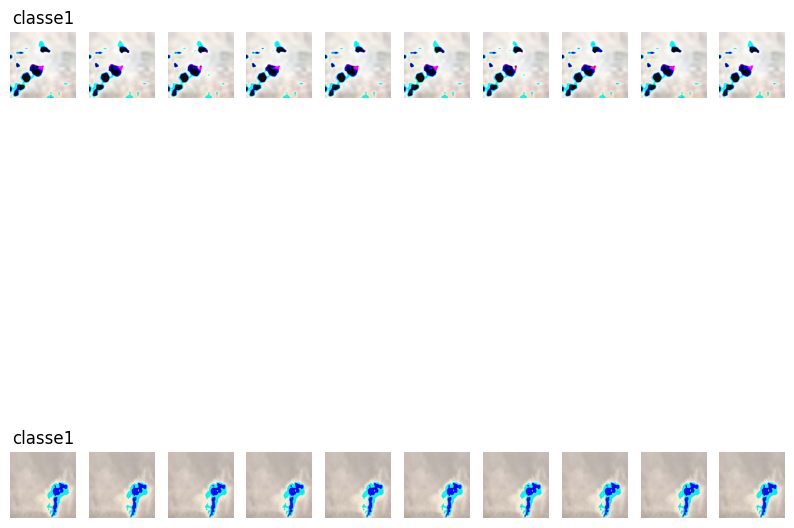

In [32]:
import matplotlib.pyplot as plt

def show_batch(image_batch, label_batch, class_names):
    plt.figure(figsize=(10,10))
    batch_size, sequence_length, _, _, _ = image_batch.shape
    for n in range(min(batch_size, 25)): 
        for seq_index in range(sequence_length):
            ax = plt.subplot(batch_size, sequence_length, n * sequence_length + seq_index + 1)
            plt.imshow(image_batch[n, seq_index].astype("uint8"))  
            if seq_index == 0:
                plt.title(class_names[np.argmax(label_batch[n])])
            plt.axis("off")

for image_batch, label_batch in train_dataset.take(1):
    show_batch(image_batch.numpy(), label_batch.numpy(), class_names=["classe1", "classe2", ...])
